In [3]:
import pandas as pd
df = pd.read_csv("data/ames.csv")


In [11]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [6]:
print('Shape:', df.shape)

Shape: (1460, 81)


In [10]:
expected = ['SalePrice', 'GrLivArea', 'OverallQual','Neighborhood','YearBuilt']
missing = [ c for c in expected if c not in df.columns]
print (expected)
print(missing)


['SalePrice', 'GrLivArea', 'OverallQual', 'Neighborhood', 'YearBuilt']
[]


In [13]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [14]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [18]:
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)
missing_tbl = missing_pct[missing_pct > 0].round(1).to_frame('missing_pct')
missing_tbl.head(20)

,missing_pct
PoolQC,99.5
MiscFeature,96.3
Alley,93.8
Fence,80.8
MasVnrType,59.7
FireplaceQu,47.3
LotFrontage,17.7
GarageYrBlt,5.5
GarageCond,5.5
GarageType,5.5


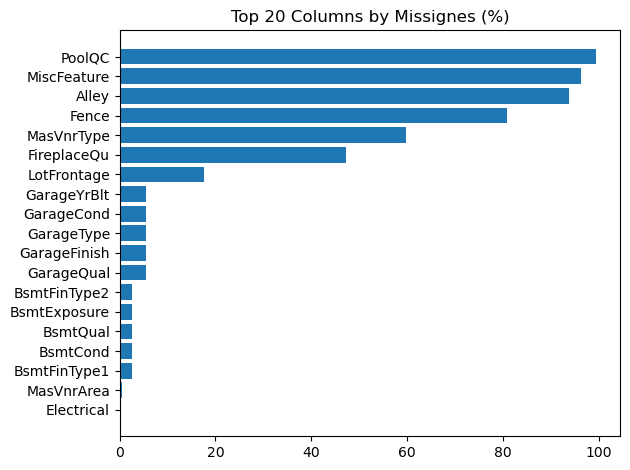

In [25]:
import matplotlib.pyplot as plt
from pathlib import Path
Path('images').mkdir(exist_ok =True)
top = missing_tbl.head(20).iloc[::-1]
plt.figure()
plt.barh(top.index, top['missing_pct'])
plt.title('Top 20 Columns by Missignes (%)')
plt.tight_layout()
plt.savefig('images/missingness_summary.png', dpi=300)
plt.show()
     

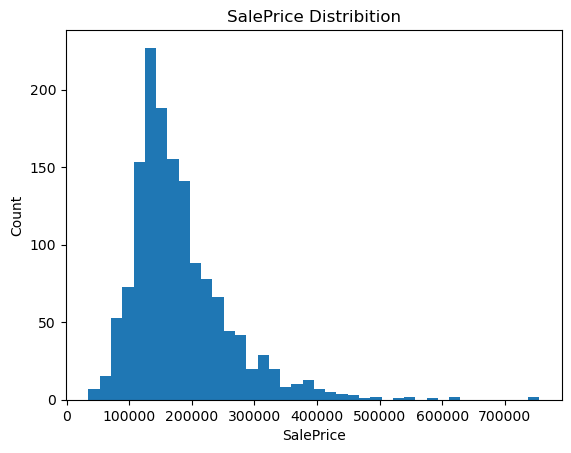

SalePrice summary:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [32]:
plt.figure()
plt.hist(df['SalePrice'], bins=40)
plt.title ('SalePrice Distribition')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.savefig('images/price_distribution.png', dpi=300)
plt.show()
print('SalePrice summary:')
display(df['SalePrice'].describe())       

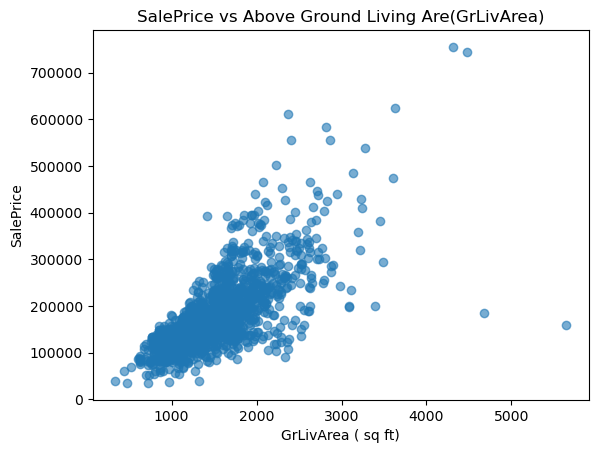

In [35]:
plt.figure()
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha =0.6)
plt.title('SalePrice vs Above Ground Living Are(GrLivArea)')
plt.xlabel ('GrLivArea ( sq ft)')
plt.ylabel('SalePrice')
plt.savefig('images/price_vs_liv_are.png',dpi=300)
plt.show()

In [39]:
num_cols =df.select_dtypes(include='number').columns
corr = df[num_cols].corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
display(corr.head(15).to_frame('corr_with_SalePrice'))

,corr_with_SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


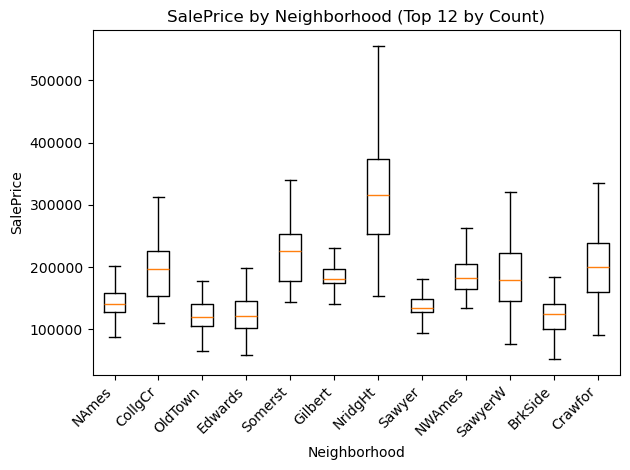

In [54]:
# # Top neighborhoods by number of listings (keeps plot readable)
import matplotlib.pyplot as plt

top_n = 12
top_neigh = df["Neighborhood"].value_counts().head(top_n).index
plot_df = df[df["Neighborhood"].isin(top_neigh)]

plt.figure()
plt.boxplot(
    [plot_df.loc[plot_df["Neighborhood"] == n, "SalePrice"] for n in top_neigh],
    tick_labels=list(top_neigh),
    showfliers=False
)
plt.title(f"SalePrice by Neighborhood (Top {top_n} by Count)")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/neighborhood_price_bands.png", dpi=200)
plt.show()
            